In [1]:
#regex tutorial
import re
import pandas as pd
from wordcloud import WordCloud
import seaborn as sns
import matplotlib.pyplot as plt
from textblob import TextBlob
import plotly.express as px
from nltk.corpus import stopwords

In [2]:
import nltk
from nltk.stem import WordNetLemmatizer

In [3]:
import scipy.stats as st

In [4]:
#dataframes
df1=pd.read_csv("C:/Users/SWRM/Downloads/dataset_google-maps-reviews-scraper-task_2025-09-21_14-28-24-893.csv")
df2=pd.read_csv("C:/Users/SWRM/Downloads/dataset_google-maps-reviews-scraper-task_2025-09-21_14-24-32-571.csv")
df3=pd.read_csv("C:/Users/SWRM/Downloads/dataset_google-maps-reviews-scraper-task_2025-09-21_14-22-11-576.csv")
df4=pd.read_csv("C:/Users/SWRM/Downloads/dataset_google-maps-reviews-scraper-task_2025-09-21_14-06-14-505.csv")
df5=pd.read_csv("C:/Users/SWRM/Downloads/dataset_google-maps-reviews-scraper-task_2025-09-21_14-04-00-751.csv")
df6=pd.read_csv("C:/Users/SWRM/Downloads/dataset_google-maps-reviews-scraper-task_2025-09-21_14-01-16-477.csv")
df7=pd.read_csv("C:/Users/SWRM/Downloads/dataset_google-maps-reviews-scraper-task_2025-09-21_13-53-10-475.csv")
df8=pd.read_csv("C:/Users/SWRM/Downloads/dataset_Google-Maps-Reviews-Scraper_2025-09-28_01-45-37-160.csv")


In [5]:
#getting title of all dataframes
print(f"Title for dataframe 1 is {df1.title.unique()}")
print(f"Title for dataframe 2 is {df2.title.unique()}")
print(f"Title for dataframe 3 is {df3.title.unique()}")
print(f"Title for dataframe 4 is {df4.title.unique()}")
print(f"Title for dataframe 5 is {df5.title.unique()}")
print(f"Title for dataframe 6 is {df6.title.unique()}")
print(f"Title for dataframe 7 is {df7.title.unique()}")
print(f"Title for dataframe 7 is {df8.title.unique()}")

Title for dataframe 1 is ['Darwin Military Museum']
Title for dataframe 2 is ['Darwin Aviation Museum']
Title for dataframe 3 is ['RFDS Darwin Tourist Facility']
Title for dataframe 4 is ['Darwin Aviation Museum']
Title for dataframe 5 is ['Museum and Art Gallery of the Northern Territory']
Title for dataframe 6 is ['RFDS Darwin Tourist Facility']
Title for dataframe 7 is ['Darwin Military Museum']
Title for dataframe 7 is ['Museum and Art Gallery of the Northern Territory']


In [6]:
#I will join dataframes with the same title, remove duplicates, then create one big dataframe comprising of all the dataframes
military_df=pd.concat([df1,df7])
aviation_df=pd.concat([df2,df4])
rfds_df=pd.concat([df3,df6])
art_df=pd.concat([df5,df8])

In [7]:
print(f"Military df duplicate count :{military_df.duplicated().sum()}")
print(f"Aviation df duplicate count :{aviation_df.duplicated().sum()}")
print(f"RFDS df duplicate count :{rfds_df.duplicated().sum()}")
print(f"Art gallery df duplicate count :{art_df.duplicated().sum()}")

Military df duplicate count :0
Aviation df duplicate count :0
RFDS df duplicate count :0
Art gallery df duplicate count :1


In [8]:
art_df.drop_duplicates(inplace=True)

In [9]:
#checking for null values
def null_checker(dataframe,df_name):
    '''
    Function will read in dataframe and return a list of all the columns with over 50 null values
    Which will later on be removed from the corresponding dataset
    
    '''
    
    null_df=dataframe.isnull().sum().to_frame()
    df_len=len(dataframe)
    print(df_len)
    null_df["null_percentage"]=(null_df[0]/df_len)*100
    null_df=null_df.loc[null_df["null_percentage"]>=50]
    dataframe=dataframe.drop(null_df.index,axis=1)
    return dataframe


In [10]:
military_df=null_checker(military_df,"military_df")
aviation_df=null_checker(aviation_df,"military_df")
rfds_df=null_checker(rfds_df,"military_df")
art_df=null_checker(art_df,"military_df")

109
126
112
278


In [11]:
art_df.isnull().sum()

address                                    0
categories/0                               0
categories/1                               0
categories/2                               0
categories/3                               0
categories/4                               0
categories/5                               0
categories/6                               0
categories/7                               0
categories/8                               0
categories/9                               0
categoryName                               0
cid                                        0
city                                       0
countryCode                                0
fid                                        0
imageUrl                                   0
isAdvertisement                            0
isLocalGuide                               0
language                                   0
likesCount                                 0
location/lat                               0
location/l

In [12]:
#removing unneccesary columns
military_df.columns

Index(['address', 'categories/0', 'categories/1', 'categories/2',
       'categories/3', 'categoryName', 'cid', 'city', 'countryCode', 'fid',
       'imageUrl', 'isAdvertisement', 'isLocalGuide', 'language', 'likesCount',
       'location/lat', 'location/lng', 'originalLanguage', 'permanentlyClosed',
       'placeId', 'postalCode', 'publishAt', 'publishedAtDate',
       'reviewContext/Reservation recommended', 'reviewContext/Visited on',
       'reviewContext/Wait time', 'reviewImageUrls/0', 'reviewImageUrls/1',
       'reviewImageUrls/2', 'reviewImageUrls/3', 'reviewImageUrls/4',
       'reviewOrigin', 'reviewerNumberOfReviews', 'reviewsCount', 'scrapedAt',
       'searchString', 'stars', 'state', 'street', 'temporarilyClosed', 'text',
       'title', 'totalScore', 'url'],
      dtype='object')

In [13]:
columns_to_drop_military_df=['address','cid', 'city', 'countryCode', 'fid',
       'imageUrl','location/lat', 'location/lng','originalLanguage', 'permanentlyClosed',
       'placeId', 'postalCode','reviewImageUrls/0', 'reviewImageUrls/1',
       'reviewImageUrls/2', 'reviewImageUrls/3', 'reviewImageUrls/4','reviewOrigin','scrapedAt','searchString','street','url']
military_df.drop(columns_to_drop_military_df,axis=1,inplace=True)

In [14]:
military_df.columns

Index(['categories/0', 'categories/1', 'categories/2', 'categories/3',
       'categoryName', 'isAdvertisement', 'isLocalGuide', 'language',
       'likesCount', 'publishAt', 'publishedAtDate',
       'reviewContext/Reservation recommended', 'reviewContext/Visited on',
       'reviewContext/Wait time', 'reviewerNumberOfReviews', 'reviewsCount',
       'stars', 'state', 'temporarilyClosed', 'text', 'title', 'totalScore'],
      dtype='object')

In [15]:
columns_to_drop_aviation=['address','cid', 'city', 'countryCode', 'fid',
       'imageUrl','location/lat', 'location/lng','originalLanguage', 'permanentlyClosed',
       'placeId', 'postalCode','reviewImageUrls/0', 'reviewImageUrls/1',
       'reviewImageUrls/2', 'reviewImageUrls/3','reviewOrigin','scrapedAt','searchString','street','url']
aviation_df.drop(columns_to_drop_aviation,axis=1,inplace=True)

In [16]:
columns_to_drop_rfds=['address','cid', 'city', 'countryCode', 'fid',
       'imageUrl','location/lat', 'location/lng','originalLanguage', 'permanentlyClosed',
       'placeId', 'postalCode','reviewImageUrls/0','reviewOrigin','scrapedAt','searchString','street','url']
rfds_df.drop(columns_to_drop_rfds,axis=1,inplace=True)

In [17]:
art_df.drop(['address','cid', 'city', 'countryCode', 'fid',
       'imageUrl','location/lat', 'location/lng','originalLanguage', 'permanentlyClosed',
       'placeId', 'postalCode','reviewOrigin','scrapedAt','searchString','street','url'],axis=1,inplace=True)

In [18]:
#cc=pd.concat([military_df,df5],axis=0)

In [19]:
#dealing with remaining null values
military_df.isnull().sum()

categories/0                              0
categories/1                              0
categories/2                              0
categories/3                              0
categoryName                              0
isAdvertisement                           0
isLocalGuide                              0
language                                  0
likesCount                                0
publishAt                                 0
publishedAtDate                           0
reviewContext/Reservation recommended    50
reviewContext/Visited on                 43
reviewContext/Wait time                  46
reviewerNumberOfReviews                   0
reviewsCount                              0
stars                                     0
state                                     0
temporarilyClosed                         0
text                                      3
title                                     0
totalScore                                0
dtype: int64

In [20]:
military_df['reviewContext/Wait time'].fillna(military_df['reviewContext/Wait time'].mode().values[0],inplace=True)
military_df['reviewContext/Reservation recommended'].fillna(military_df['reviewContext/Reservation recommended'].mode().values[0],inplace=True)
military_df['reviewContext/Visited on'].fillna(military_df['reviewContext/Visited on'].mode().values[0],inplace=True)

In [21]:
military_df.dropna(inplace=True)
military_df.isnull().sum()

categories/0                             0
categories/1                             0
categories/2                             0
categories/3                             0
categoryName                             0
isAdvertisement                          0
isLocalGuide                             0
language                                 0
likesCount                               0
publishAt                                0
publishedAtDate                          0
reviewContext/Reservation recommended    0
reviewContext/Visited on                 0
reviewContext/Wait time                  0
reviewerNumberOfReviews                  0
reviewsCount                             0
stars                                    0
state                                    0
temporarilyClosed                        0
text                                     0
title                                    0
totalScore                               0
dtype: int64

In [22]:
aviation_df['reviewContext/Wait time'].fillna(aviation_df['reviewContext/Wait time'].mode().values[0],inplace=True)
aviation_df['reviewContext/Reservation recommended'].fillna(aviation_df['reviewContext/Reservation recommended'].mode().values[0],inplace=True)
aviation_df['reviewContext/Visited on'].fillna(aviation_df['reviewContext/Visited on'].mode().values[0],inplace=True)

In [23]:
aviation_df.dropna(inplace=True)
aviation_df.isnull().sum()

categories/0                             0
categories/1                             0
categories/2                             0
categories/3                             0
categories/4                             0
categoryName                             0
isAdvertisement                          0
isLocalGuide                             0
language                                 0
likesCount                               0
publishAt                                0
publishedAtDate                          0
reviewContext/Reservation recommended    0
reviewContext/Visited on                 0
reviewContext/Wait time                  0
reviewerNumberOfReviews                  0
reviewsCount                             0
stars                                    0
state                                    0
temporarilyClosed                        0
text                                     0
title                                    0
totalScore                               0
dtype: int6

In [24]:
rfds_df.isnull().sum()

categories/0                              0
categories/1                              0
categories/2                              0
categories/3                              0
categoryName                              0
isAdvertisement                           0
isLocalGuide                              0
language                                  0
likesCount                                0
publishAt                                 0
publishedAtDate                           0
responseFromOwnerDate                     7
responseFromOwnerText                     7
reviewContext/Reservation recommended    50
reviewContext/Visited on                 44
reviewContext/Wait time                  45
reviewerNumberOfReviews                   0
reviewsCount                              0
stars                                     0
state                                     0
temporarilyClosed                         0
text                                      6
title                           

In [25]:
rfds_df['reviewContext/Wait time'].fillna(rfds_df['reviewContext/Wait time'].mode().values[0],inplace=True)
rfds_df['reviewContext/Reservation recommended'].fillna(rfds_df['reviewContext/Reservation recommended'].mode().values[0],inplace=True)
rfds_df['reviewContext/Visited on'].fillna(rfds_df['reviewContext/Visited on'].mode().values[0],inplace=True)

In [26]:
rfds_df.dropna(inplace=True)
rfds_df.isnull().sum()

categories/0                             0
categories/1                             0
categories/2                             0
categories/3                             0
categoryName                             0
isAdvertisement                          0
isLocalGuide                             0
language                                 0
likesCount                               0
publishAt                                0
publishedAtDate                          0
responseFromOwnerDate                    0
responseFromOwnerText                    0
reviewContext/Reservation recommended    0
reviewContext/Visited on                 0
reviewContext/Wait time                  0
reviewerNumberOfReviews                  0
reviewsCount                             0
stars                                    0
state                                    0
temporarilyClosed                        0
text                                     0
title                                    0
totalScore 

In [27]:
art_df['reviewContext/Wait time'].fillna("None",inplace=True)
art_df['reviewContext/Reservation recommended'].fillna("None",inplace=True)
art_df['reviewContext/Visited on'].fillna("None",inplace=True)

In [28]:
art_df.dropna(inplace=True)
art_df.isnull().sum()

categories/0                             0
categories/1                             0
categories/2                             0
categories/3                             0
categories/4                             0
categories/5                             0
categories/6                             0
categories/7                             0
categories/8                             0
categories/9                             0
categoryName                             0
isAdvertisement                          0
isLocalGuide                             0
language                                 0
likesCount                               0
publishAt                                0
publishedAtDate                          0
reviewContext/Reservation recommended    0
reviewContext/Visited on                 0
reviewContext/Wait time                  0
reviewImageUrls/0                        0
reviewImageUrls/1                        0
reviewerNumberOfReviews                  0
reviewsCoun

In [29]:
art_df.drop(["reviewImageUrls/0","reviewImageUrls/1"],axis=1,inplace=True)

In [30]:
#concating all the data
military_aviation=pd.concat([military_df,aviation_df])
rfds_df5=pd.concat([rfds_df,art_df])
df=pd.concat([military_aviation,rfds_df5])

In [31]:
df.fillna("None",inplace=True)

In [32]:
df.isnull().sum()

categories/0                             0
categories/1                             0
categories/2                             0
categories/3                             0
categoryName                             0
isAdvertisement                          0
isLocalGuide                             0
language                                 0
likesCount                               0
publishAt                                0
publishedAtDate                          0
reviewContext/Reservation recommended    0
reviewContext/Visited on                 0
reviewContext/Wait time                  0
reviewerNumberOfReviews                  0
reviewsCount                             0
stars                                    0
state                                    0
temporarilyClosed                        0
text                                     0
title                                    0
totalScore                               0
categories/4                             0
responseFro

## First, we will run the dataframe through Textblob and return sentiment column

In [33]:
def classify_emotion(review):
    analysis = TextBlob(review)
    if analysis.sentiment.polarity >0:
        return 'Positive' 
    elif analysis.sentiment.polarity <0:
        return 'Negative'       
    else:
        return 'Neutral'

In [34]:
sentiment_list=[]
translation_dictionary={
    'Entrada gratuita y se agradece mucho, me encantó conocer más sobre la cultura Tiwi, las instalaciones son bellas y el personal amable':'Admission is free, and donations are much appreciated. I loved learning more about the Tiwi culture. The facilities are beautiful and the staff is friendly.',
    'Spændende sted, med både kunst, natur, skibsfart og en særlig spændende udstilling om den orkan der ramte Darwin i 1974. Og så er det gratis at komme ind':'An exciting place, with art, nature, shipping, and a particularly interesting exhibition about the hurricane that hit Darwin in 1974. And admission is free',
    "Zeer educatief en mooi', 'Nor open": 'Very educational and beautiful. Not open',
    "Un museo che mostra( finalmente) arte aborigena. Per chi ama poi la storia, si può rivivere il terribile uragano che distrusse quasi completamente la città con delle mappe per quartiere che mostrano la rovina di quell'evento e come è stata riedificatavsulle macerie tutta la città.":'A museum that finally showcases Aboriginal art. For those who love history, you can relive the terrible hurricane that almost completely destroyed the city with neighborhood maps showing the ruin from that event and how the entire city was rebuilt from the rubble'
    
    
}
df["text"].replace(translation_dictionary,inplace=True)
for i,row in df.iterrows():
    sentiment_list.append(classify_emotion(row["text"]))
df["sentiment"]=sentiment_list    

In [35]:
df.sentiment.unique()

array(['Positive', 'Negative', 'Neutral'], dtype=object)

In [36]:
#returning counts of each
df.sentiment.value_counts().to_frame()

,count
sentiment,
Positive,451
Negative,16
Neutral,10


In [37]:
for n in df.title.unique():
    print(n)
    print(len(df.loc[df["title"]==n]))

Darwin Military Museum
106
Darwin Aviation Museum
117
RFDS Darwin Tourist Facility
99
Museum and Art Gallery of the Northern Territory
155


In [38]:
df=df[['categoryName', 'isAdvertisement', 'isLocalGuide', 'language',
       'likesCount', 'publishAt', 'publishedAtDate',
       'reviewContext/Reservation recommended', 'reviewContext/Visited on',
       'reviewContext/Wait time', 'reviewerNumberOfReviews', 'reviewsCount',
       'stars', 'state', 'temporarilyClosed', 'text', 'title', 'totalScore',
        'responseFromOwnerDate', 'responseFromOwnerText','sentiment']]

In [39]:
df_parks=pd.read_csv("C:/Users/SWRM/Desktop/winning nlp notes/parks_cul.csv")

In [40]:
df_parks.isnull().sum()

Unnamed: 0                                 0
categoryName                               0
isAdvertisement                            0
isLocalGuide                               0
language                                   0
likesCount                                 0
publishAt                                  0
publishedAtDate                            0
reviewContext/Reservation recommended    898
reviewContext/Visited on                 898
reviewContext/Wait time                  898
reviewerNumberOfReviews                    0
reviewsCount                               0
stars                                      0
state                                      0
temporarilyClosed                          0
text                                      51
title                                      0
totalScore                                 0
responseFromOwnerDate                    998
responseFromOwnerText                    998
sentiment                                  0
dtype: int

In [41]:
for n in ["reviewContext/Reservation recommended","reviewContext/Visited on","reviewContext/Wait time","responseFromOwnerDate","responseFromOwnerText"]:
    df_parks[n].fillna("None",inplace=True)
df_parks.isnull().sum()


Unnamed: 0                                0
categoryName                              0
isAdvertisement                           0
isLocalGuide                              0
language                                  0
likesCount                                0
publishAt                                 0
publishedAtDate                           0
reviewContext/Reservation recommended     0
reviewContext/Visited on                  0
reviewContext/Wait time                   0
reviewerNumberOfReviews                   0
reviewsCount                              0
stars                                     0
state                                     0
temporarilyClosed                         0
text                                     51
title                                     0
totalScore                                0
responseFromOwnerDate                     0
responseFromOwnerText                     0
sentiment                                 0
dtype: int64

In [42]:
df_parks.dropna(inplace=True)

In [43]:
dff=pd.concat([df,df_parks])
dff.drop('Unnamed: 0',inplace=True,axis=1)


In [44]:
dff.drop_duplicates("text",inplace=True)

In [45]:
dff.isnull().sum()

categoryName                             0
isAdvertisement                          0
isLocalGuide                             0
language                                 0
likesCount                               0
publishAt                                0
publishedAtDate                          0
reviewContext/Reservation recommended    0
reviewContext/Visited on                 0
reviewContext/Wait time                  0
reviewerNumberOfReviews                  0
reviewsCount                             0
stars                                    0
state                                    0
temporarilyClosed                        0
text                                     0
title                                    0
totalScore                               0
responseFromOwnerDate                    0
responseFromOwnerText                    0
sentiment                                0
dtype: int64

## Now we will identify columns that are logical to analyze, then we will dive into the remaining columns later on for trend analysis

In [46]:
df_filtered=dff[['isAdvertisement', 'isLocalGuide', 'language',
       'likesCount','reviewContext/Reservation recommended', 'reviewContext/Visited on',
       'reviewContext/Wait time', 'reviewerNumberOfReviews', 'reviewsCount',
       'stars','temporarilyClosed', 'text','totalScore',
       'responseFromOwnerDate', 'responseFromOwnerText','sentiment']].copy()

## Univariate analysis

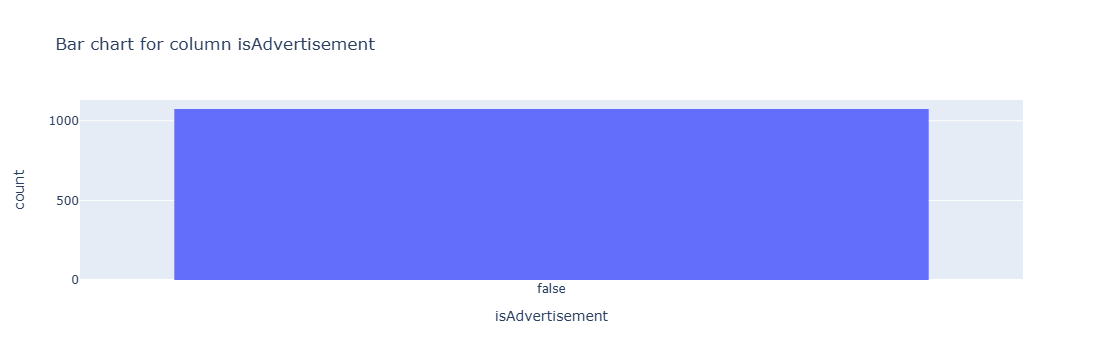

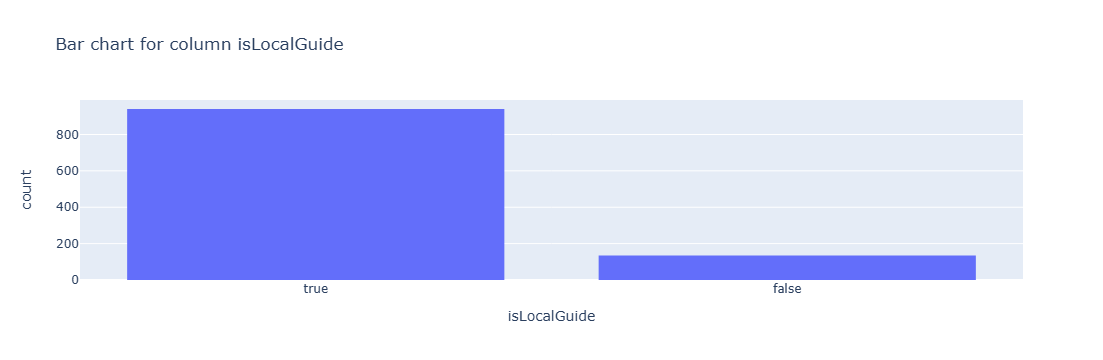

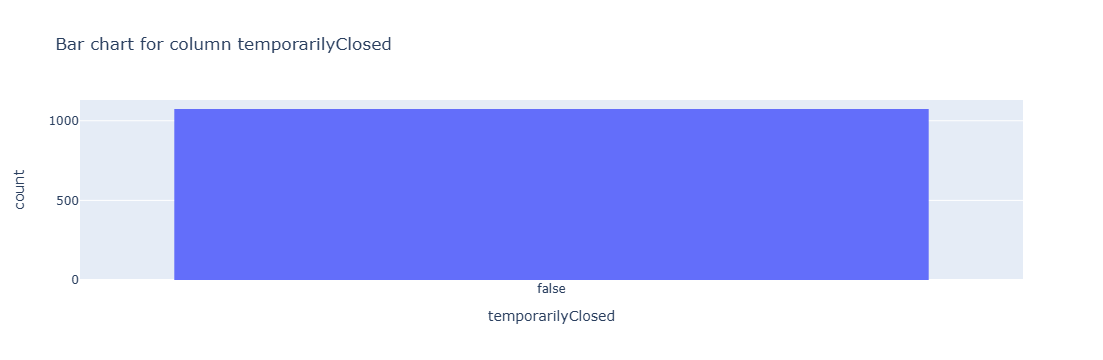

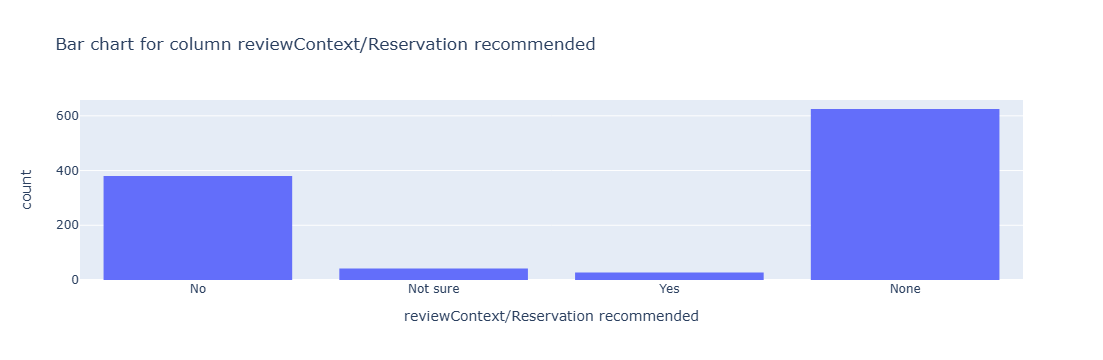

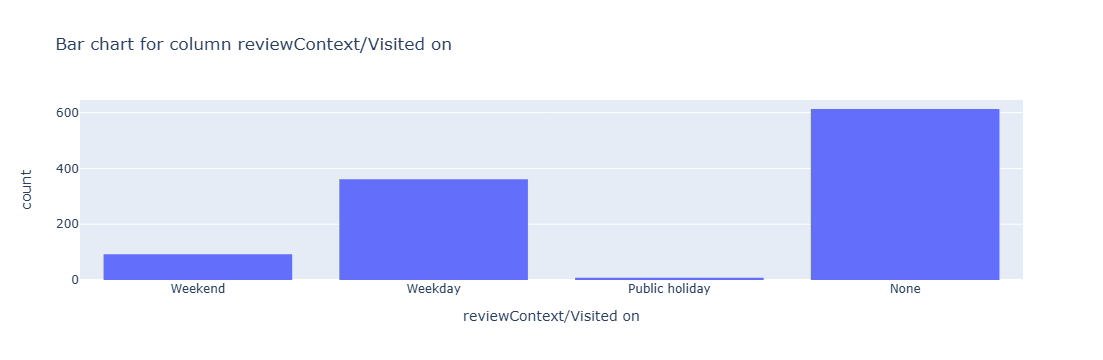

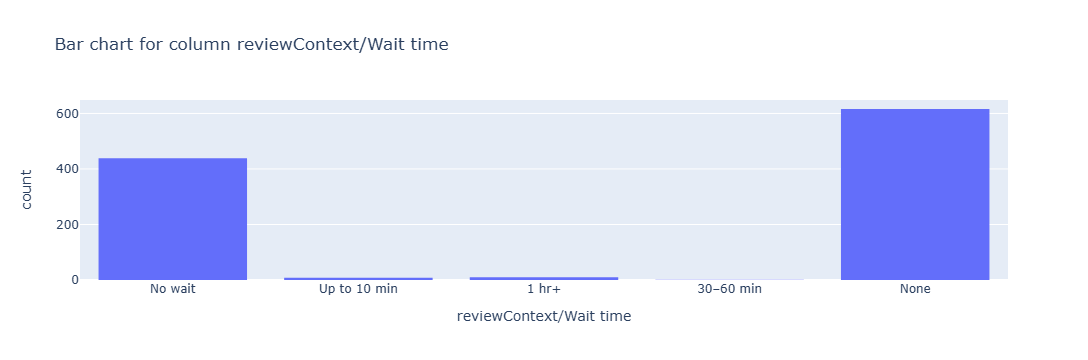

In [47]:
#analyzing categorical data first
for n in ['isAdvertisement','isLocalGuide','temporarilyClosed','reviewContext/Reservation recommended',
       'reviewContext/Visited on', 'reviewContext/Wait time']:
    fig=px.histogram(data_frame=df_filtered,x=n, title=f"Bar chart for column {n}")
    fig.show()
    

## Categorical to categorical univariate analysis 
1. Is advertisement: All of the data from the museums have not been advertized. We will remove this column.
2. Is Local guide: 940 out of 1074 of the dataset had local guides with them, which makes up for 87.5 percent. Could those that didn't have guides have received negative reviews?
3. Temporarily closed : All false, we will remove this column.
4. Review context reservation recommended: This describes the review based on the tourist being required to reserve the trip or not. 58 percent of the reviews are none, 35% didn't need, and 3 percent were unsure, leaving only 2.5 percent who needed to reserve. Considering that most are none, we will ignore.
5. Review context viewed on: Ignore.
6. Review context wait time: Ignore


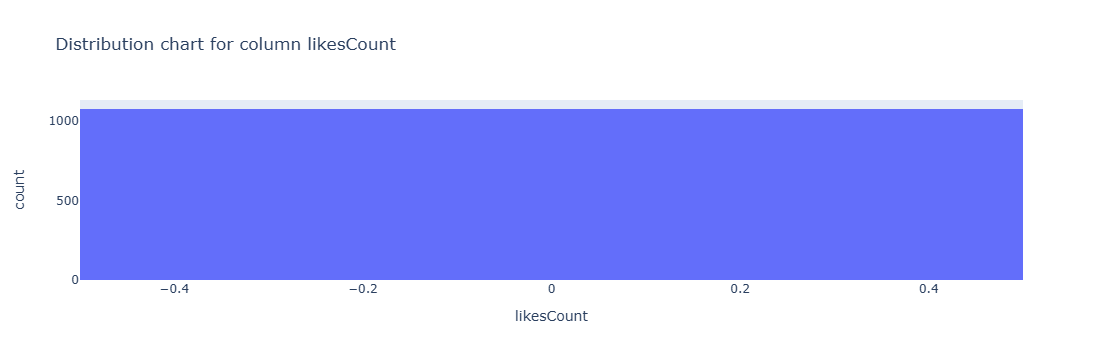

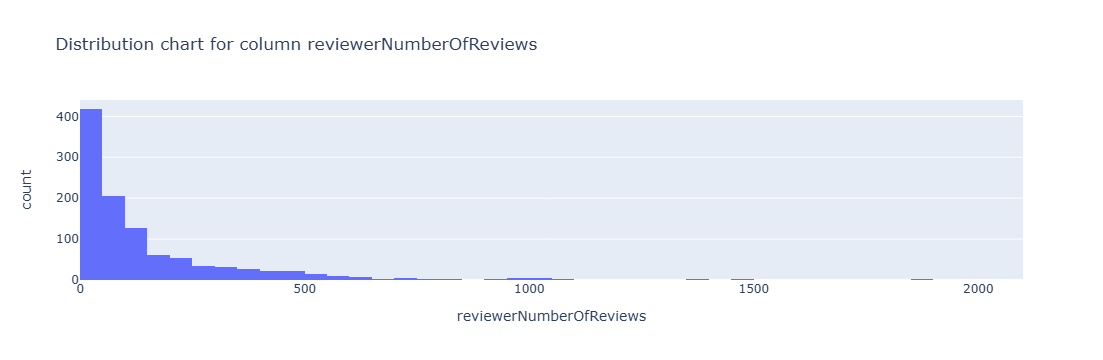

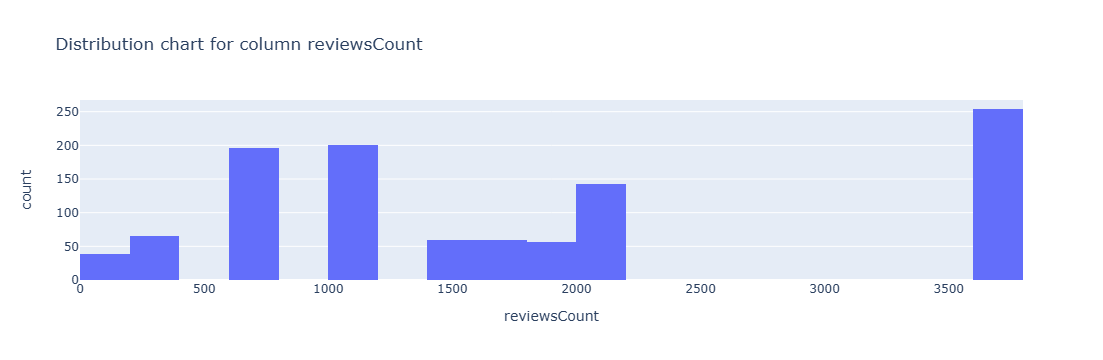

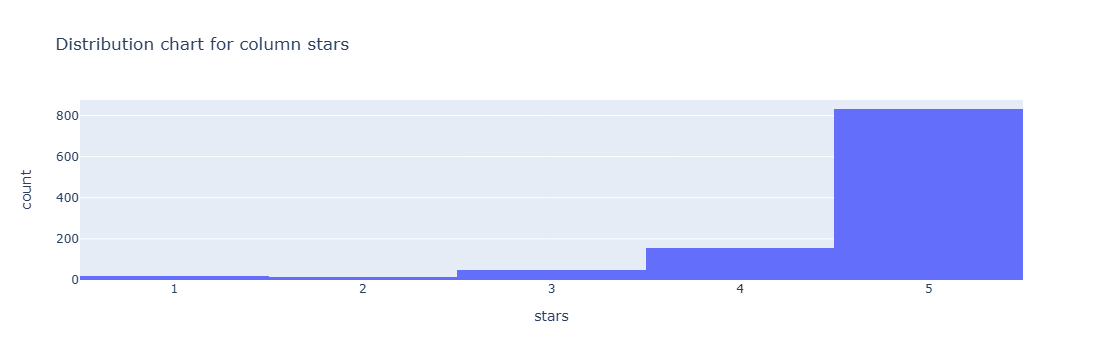

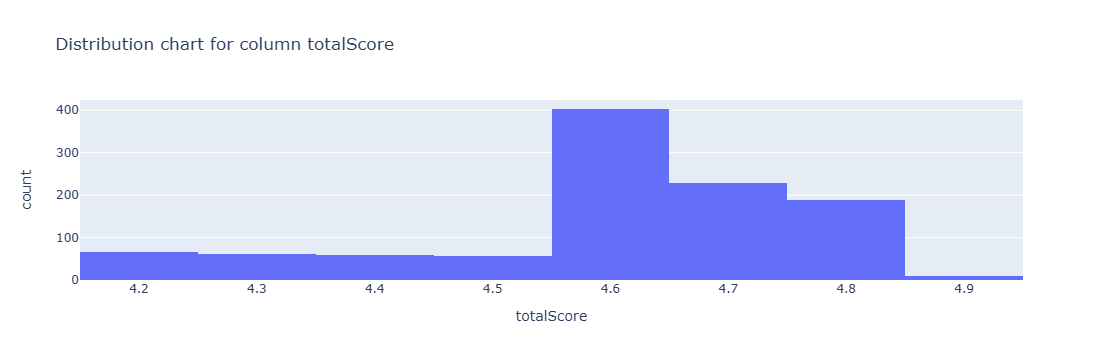

In [48]:
for i in dff.select_dtypes([int,float]).columns:
    fig=px.histogram(data_frame=df_filtered,x=i, title=f"Distribution chart for column {i}")
    fig.show()



In [49]:
df.select_dtypes(["int","float"]).describe()

,likesCount,reviewerNumberOfReviews,reviewsCount,stars,totalScore
count,477.0,477.000000,477.000000,477.000000,477.000000
mean,0.0,177.104822,2179.400419,4.761006,4.645283
std,0.0,247.266989,1103.674210,0.559026,0.049829
min,0.0,0.000000,1072.000000,1.000000,4.600000
25%,0.0,30.000000,1196.000000,5.000000,4.600000
50%,0.0,89.000000,2118.000000,5.000000,4.600000
75%,0.0,233.000000,3672.000000,5.000000,4.700000
max,0.0,1856.000000,3672.000000,5.000000,4.700000


## Numeric to numeric analysis

1. Likes count: We will remove it.
2. Reviewers number of reviews: This is the number of reviews the review got. The column is righly skewed, with an median of 89, min of 0 and max of 1856. We can create a column called reviewers_review_number_class and create groups, then identify what makesup these different variations and how they relate to the sentiment?
4. Reviews count: Number of total reviews for each museum.
5. Stars: This column is leftly skewed, with an average of 5, minimum of 1 and max of 5.
6. Total score: Is the overal rating of the experience, the column is mostly uniform with an average of 4.65, with a max of 4.7 and a min of 4.6. There isn't much variation in this one, so we will drop it.

In [50]:
dff.columns

Index(['categoryName', 'isAdvertisement', 'isLocalGuide', 'language',
       'likesCount', 'publishAt', 'publishedAtDate',
       'reviewContext/Reservation recommended', 'reviewContext/Visited on',
       'reviewContext/Wait time', 'reviewerNumberOfReviews', 'reviewsCount',
       'stars', 'state', 'temporarilyClosed', 'text', 'title', 'totalScore',
       'responseFromOwnerDate', 'responseFromOwnerText', 'sentiment'],
      dtype='object')

In [51]:
dff.drop(["likesCount","totalScore","isAdvertisement","temporarilyClosed", 'reviewContext/Reservation recommended', 'reviewContext/Visited on',
       'reviewContext/Wait time'],axis=1,inplace=True)
df_filtered.drop(["likesCount","totalScore","isAdvertisement","temporarilyClosed", 'reviewContext/Reservation recommended', 'reviewContext/Visited on',
       'reviewContext/Wait time'],axis=1,inplace=True)

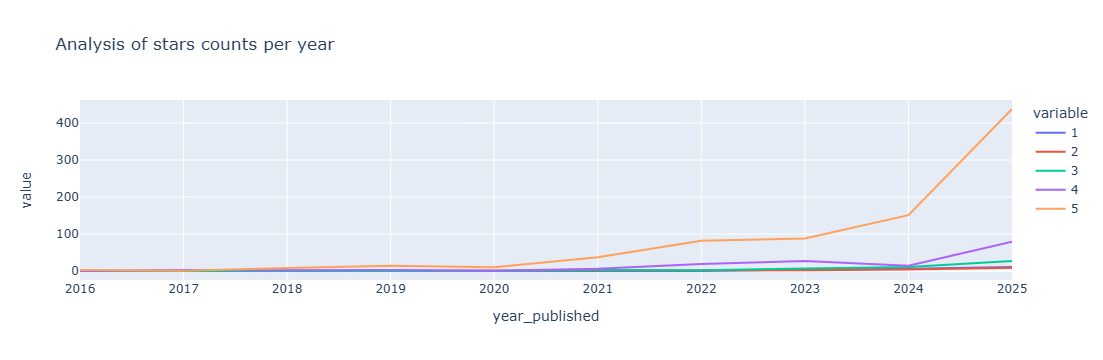

In [52]:
dff["year_published"]=dff['publishedAtDate'].apply(lambda x: x.split("-")[0])
grouped_stars=pd.crosstab(index=dff["year_published"],columns=dff["stars"]).reset_index()
fig4=px.line(grouped_stars,x="year_published",y=[1,2,3,4,5],title="Analysis of stars counts per year")
fig4.show()


In [53]:
before_2021=dff.loc[(dff["year_published"]=="2020")|(dff["year_published"]=="2019") | (dff["year_published"]=="2018") | (dff["year_published"]=="2017") | (dff["year_published"]=="2016")]

In [54]:
after_2021=dff.loc[(dff["year_published"]=="2021")|(dff["year_published"]=="2022") | (dff["year_published"]=="2023") | (dff["year_published"]=="2024") | (dff["year_published"]=="2025")]

In [55]:
dff.loc[dff["year_published"]=="2022"]["stars"].value_counts()

stars
5    82
4    19
3     2
2     1
Name: count, dtype: int64

In [56]:
before_2021.columns

Index(['categoryName', 'isLocalGuide', 'language', 'publishAt',
       'publishedAtDate', 'reviewerNumberOfReviews', 'reviewsCount', 'stars',
       'state', 'text', 'title', 'responseFromOwnerDate',
       'responseFromOwnerText', 'sentiment', 'year_published'],
      dtype='object')

Four and five star reviews have grown from 2020 till date. Why is that so? Also which museums are contributing towards this growth?

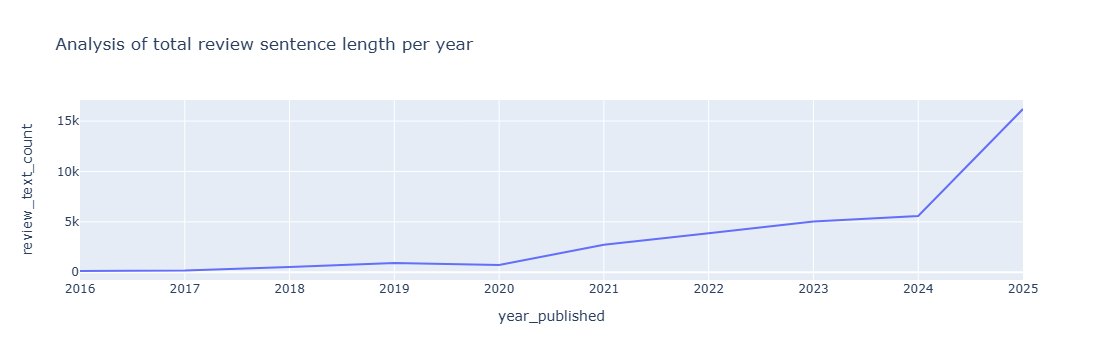

In [57]:
dff["review_text_count"]=dff["text"].apply(lambda x: len(x.split(" ")))
grouped_text_len=dff.groupby("year_published")["review_text_count"].sum().reset_index()
fig5=px.line(grouped_text_len,x="year_published",y="review_text_count",title="Analysis of total review sentence length per year")
fig5.show()


The length of reviews left has also increased as well from 2020 going onwards.

In [58]:
dff.

SyntaxError: invalid syntax (652847016.py, line 1)

In [59]:
after_2021.sentiment.value_counts()

sentiment
Positive    894
Neutral      92
Negative     43
Name: count, dtype: int64

## Text preprocessing

## Topic modelling

In [60]:

def clean_text(text):
    # 1. Remove URLs, Emails, Tags (unchanged)
    url_pattern = r'https?://\S+|www\.\S+|\S+\.\S+/\S+|\ftp\.\S+'
    text = re.sub(url_pattern, '', text)
    email_pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'
    text = re.sub(email_pattern, '', text)
    tag_pattern = r'[#@]\w+'
    text = re.sub(tag_pattern, '', text)
    
    # 4. Optional: Clean up extra spaces, Lowercase, Remove Punctuation (unchanged)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    
    # Initialize the list to store *all* cleaned sentences
    cleaned_sentence_list = [] 
    
    # 5. Tokenizing
    sentences = nltk.sent_tokenize(text) # Renamed 'text' to 'sentences' for clarity
    lemma = WordNetLemmatizer()
    
    # Iterate through the list of sentences
    for sentence in sentences: 
        # words is a list of tokens in the sentence
        words = nltk.word_tokenize(sentence) 
        
        # Lemmatize and remove stop words
        words = [
            lemma.lemmatize(word) 
            for word in words 
            if word not in set(stopwords.words("english"))
        ]
        
        # Join the words back into a cleaned sentence string
        cleaned_sentence = " ".join(words) 
        
        # APPEND the cleaned sentence string to the list
        cleaned_sentence_list.append(cleaned_sentence) 
        
    # Final step: Join all cleaned sentence strings into one single text block
    final_cleaned_text = " ".join(cleaned_sentence_list)
    
    return final_cleaned_text

#tokenizing function
def sent_to_words(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))

#word cloud function
def word_cloud(topic_dict,n):
        stopwords_set=set(stopwords.words("english"))
        stopwords_set.add("darwin")
        wordcloud = WordCloud(
                width=800,
                height=400,
                background_color='white',
                max_words=100,
                stopwords=stopwords_set
            ).generate_from_frequencies(topic_dict)
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")
        plt.title(f"Word cloud for topic {n}")
        plt.show()




In [61]:
#pip install gensim
#install if you haven't
import gensim
from gensim.utils import simple_preprocess
import gensim.corpora as corpora
from gsdmm import MovieGroupProcess

In [62]:
for index,row in dff.iterrows():
    dff.loc[index, "cleaned_text"] = clean_text(row["text"])

dff["cleaned_text"]=dff["cleaned_text"].apply(lambda x: x.strip())

In [63]:
import numpy as np

In [64]:
for index,row in df.iterrows():
   df.loc[index, "cleaned_text"] = clean_text(row["text"])


#df["cleaned_text"]=df["cleaned_text"].apply(lambda x: x.strip()) 
def topic_modelling(df,num):
    data = df["cleaned_text"].values.tolist()
    data_words = list(sent_to_words(data))
    
    # Create Dictionary
    id2word = corpora.Dictionary(data_words)
    
    # Create Corpus
    texts = data_words
    
    # Term Document Frequency
    corpus = [id2word.doc2bow(text) for text in texts]
    
    # View
    print(corpus[:1][0][:30])
    
    #RUNNING MODEL 
    vocab_length=len(id2word)
    # K refers to the number of clusters you need, for this case, since they are all museums, I made them one
    #So when we combine our datasets adn run through the model, we will set K to the 4
    #N_iters is the number of times the model will run to converging.
    #Alpha makes the model consolidate words into existing large clusters, hence preventing the creation of unncessary small clusters
    #Beta This encourages words to be assigned to a topic based on how frequently they already appear in that specific topic
    K=num
    gsdmm = MovieGroupProcess(K=K, alpha=0.1, beta=0.1, n_iters=30)
    # fit GSDMM model
    y = gsdmm.fit(data_words, vocab_length)
    
    doc_counts = gsdmm.cluster_doc_count
    
    # Get the indices of the top 3 topics
    top_topic_indices = sorted(
        range(len(doc_counts)), 
        key=lambda i: doc_counts[i], 
        reverse=True
    )[:num] 
    
    all_word_distributions = gsdmm.cluster_word_distribution
    top_3_topic_clusters = {}

    # 2. Extract and store the top 20 words for each of the top 3 topics
    for rank, topic_index in enumerate(top_topic_indices):
        
        # Get the word distribution for the specific topic index
        topic_distribution = all_word_distributions[topic_index]
        
        # Sort and take the top 20 words
        top_words = sorted(
            topic_distribution.items(), 
            key=lambda k: k[1], 
            reverse=True
        )[:25] 
        
        # Store as a dictionary for easy use
        topic_name = f'Topic_{rank+1}_Index_{topic_index}'
        top_3_topic_clusters[topic_name] = dict(top_words)

    for n in top_3_topic_clusters.keys():
        print("-----------------------")
        word_cloud(top_3_topic_clusters[n],n)

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1)]
In stage 0: transferred 0 clusters with 1 clusters populated
In stage 1: transferred 0 clusters with 1 clusters populated
In stage 2: transferred 0 clusters with 1 clusters populated
In stage 3: transferred 0 clusters with 1 clusters populated
In stage 4: transferred 0 clusters with 1 clusters populated
In stage 5: transferred 0 clusters with 1 clusters populated
In stage 6: transferred 0 clusters with 1 clusters populated
In stage 7: transferred 0 clusters with 1 clusters populated
In stage 8: transferred 0 clusters with 1 clusters populated
In stage 9: transferred 0 clusters with 1 clusters populated
In stage 10: transferred 0 clusters with 1 clusters populated
In stage 11: transferred 0 clusters with 1 clusters populated
In stage 12: transferred 0 clusters with 1 cluster

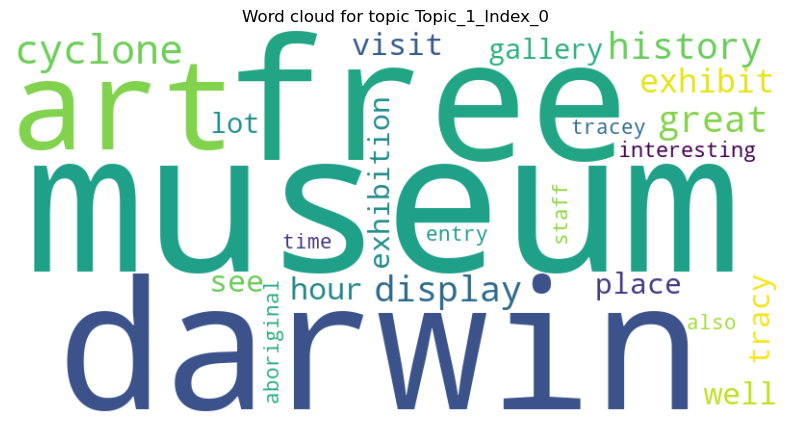

In [65]:
#museums
topic_modelling(df,1)

In [66]:
df.columns

Index(['categoryName', 'isAdvertisement', 'isLocalGuide', 'language',
       'likesCount', 'publishAt', 'publishedAtDate',
       'reviewContext/Reservation recommended', 'reviewContext/Visited on',
       'reviewContext/Wait time', 'reviewerNumberOfReviews', 'reviewsCount',
       'stars', 'state', 'temporarilyClosed', 'text', 'title', 'totalScore',
       'responseFromOwnerDate', 'responseFromOwnerText', 'sentiment',
       'cleaned_text'],
      dtype='object')

In [67]:
for n,i in df.iterrows():
    if "staff" in i["cleaned_text"].split(" "):
        print(i["cleaned_text"])
        print(i['publishedAtDate'])
        print("*******")
        print(i["title"])
        

great place spend couple hour interesting exhibition lot history culture friendly staff downside bicycle parking shaded wanting return melted saddle park accross road ski club
2025-09-08T03:51:50.357Z
*******
Darwin Military Museum
museum exceeded expectation especially free interesting lovely staff also great cafe wonderful gift shop youre looking special aboriginal momento well worth visiting
2025-04-19T06:44:06.934Z
*******
Darwin Military Museum
museum art gallery northern territory mustvisit destination darwin offer fascinating exhibition first nation culture region history marine life even dramatic story cyclone tracy admission free staff exceptionally welcoming knowledgeable making memorable experience visitor age
2025-07-27T08:05:24.782Z
*******
Darwin Military Museum
amazing glad decide activity lot see learn big really interesting free entry place amazing staff friendly helpful finish browsing place favour go cafe bite really highly recommend
2025-07-16T05:05:01.927Z
*******


[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 2), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 2), (27, 1), (28, 1), (29, 1)]
In stage 0: transferred 0 clusters with 1 clusters populated
In stage 1: transferred 0 clusters with 1 clusters populated
In stage 2: transferred 0 clusters with 1 clusters populated
In stage 3: transferred 0 clusters with 1 clusters populated
In stage 4: transferred 0 clusters with 1 clusters populated
In stage 5: transferred 0 clusters with 1 clusters populated
In stage 6: transferred 0 clusters with 1 clusters populated
In stage 7: transferred 0 clusters with 1 clusters populated
In stage 8: transferred 0 clusters with 1 clusters populated
In stage 9: transferred 0 clusters with 1 clusters populated
In stage 10: transferred 0 clusters with 1 clusters populated
In stage 11: transferred 0 clusters with 1 clusters populated
In st

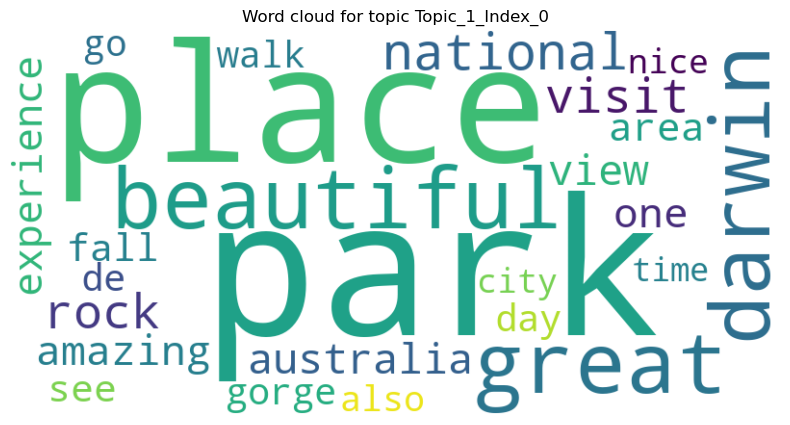

In [68]:
topic_modelling(dff.loc[dff["categoryName"]=='National park'],1)

In [69]:
#park
for n,i in dff.loc[dff["categoryName"]=='National park'].iterrows():
    if "gorge" in i["text"].split(" "):
        print(i["text"])
        print("*******")
        print(i["title"])
        

Cruised through an ancient gorge system. These sandstones in the Katherine Gorge are 1600 million years old.
Very sweaty and lots of flies. But still worth the 7 - hour drive overnight trip from TC.
P. S. Where the 2007 Rogue crocodile movie was shot and the final pitstop of the Amazing Race Australia 2019.
*******
Nitmiluk National Park
Wow wow wow ! Nous avons choisi l’expérience en canoë avec aucun regret (demi journée)! Nous nous sommes garés au premier parking mais apparemment il y en a un plus proche de l’accueil pour la location de canoë. Sachez qu’il y a un coffee shop a l’entrée du parc, donc si vous n’avez pas pris votre café ou snack, il y a de quoi faire si vous arrivez en avance. Vous faites le premier gorge bateau et c’est entre le premier et second gorge que vous récupérez votre canoë. Nous avons fait l’aller retour jusqu’au début du 4eme gorge et nous nous sommes posés au début du deuxième gorge. Spot parfait pour se baigner. Je vous recommande de prendre les prospectus

In [70]:
dff["categoryName"].unique()

array(['War museum', 'Museum', 'Tourist attraction', 'National park',
       'Movie theater', 'Market', 'Art gallery', "Farmers' market",
       'Corporate office'], dtype=object)

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1)]
In stage 0: transferred 0 clusters with 1 clusters populated
In stage 1: transferred 0 clusters with 1 clusters populated
In stage 2: transferred 0 clusters with 1 clusters populated
In stage 3: transferred 0 clusters with 1 clusters populated
In stage 4: transferred 0 clusters with 1 clusters populated
In stage 5: transferred 0 clusters with 1 clusters populated
In stage 6: transferred 0 clusters with 1 clusters populated
In stage 7: transferred 0 clusters with 1 clusters populated
In stage 8: transferred 0 clusters with 1 clusters populated
In stage 9: transferred 0 clusters with 1 clusters populated
In stage 10: transferred 0 clusters with 1 clusters populated
In stage 11: transferred 0 clusters with 1 clusters populated
In stage 12: transferred 0 clusters with 1 clusters populated
In stage 13: transferred 0 clusters with 1 clusters populated
In stage 14: transferred 0 clusters with 1 clusters populated
In stage 15: tr

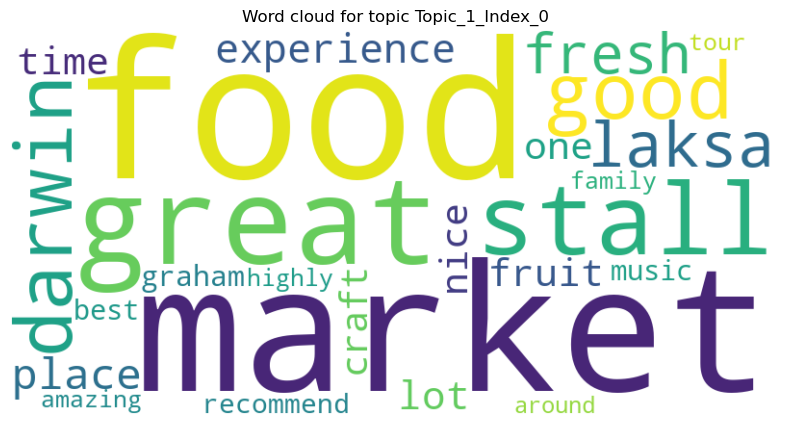

In [71]:
#market
topic_modelling(dff.loc[(dff["categoryName"]=='Market') |( dff["categoryName"]=="Farmers' market") | ( dff["categoryName"]=="Corporate office")],1)

In [72]:
for n,i in dff.loc[(dff["categoryName"]=='Market') |( dff["categoryName"]=="Farmers' market") | ( dff["categoryName"]=="Corporate office")].iterrows():
    if "laksa" in i["text"].split(" "):
        print(i["text"])
        print("*******")
        print(i["title"])

It’s my first time in Darwin and I heard so much about how good the laksa is in Darwin, When I arrived at the market I saw there was a long queue at Mary Laksa, the much hype of the laksa. After I have bought the combination laksa, the first thing I did was to taste the broth. My goodness it’s nothing like Laksa! Far from it. I suppose most of the laksa stall owners are not from Malaysia or Singapore. It’s also fell short of the taste in Sydney, Melbourne or Brisbane. For goodness sake, even if you have not been to Malaysia or Singapore, at least taste some laksa before cooking laksa. The ingredients in the laksa are laughable, there are cauliflower, bumpkins, long beans, wan tans, fake crab sticks, etc. At the end I threw away about 90% of the laksa.
*******
Parap Village Markets
Parap Market is one of my favourites in Darwin. It’s open every Saturday from 8 am to 2 pm, all year round; but it’s especially lovely during the dry season. The weather in July is absolutely delicious; cool 

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1)]
In stage 0: transferred 0 clusters with 1 clusters populated
In stage 1: transferred 0 clusters with 1 clusters populated
In stage 2: transferred 0 clusters with 1 clusters populated
In stage 3: transferred 0 clusters with 1 clusters populated
In stage 4: transferred 0 clusters with 1 clusters populated
In stage 5: transferred 0 clusters with 1 clusters populated
In stage 6: transferred 0 clusters with 1 clusters populated
In stage 7: transferred 0 clusters with 1 clusters populated
In stage 8: transferred 0 clusters with 1 clusters populated
In stage 9: transferred 0 clusters with 1 clusters populated
In stage 10: transferred 0 clusters with 1 clusters populated
In stage 11: transferred 0 clusters with 1 clusters populated
In stage 12: transferred 0 clusters with 1 clusters populated
In stage 13: tr

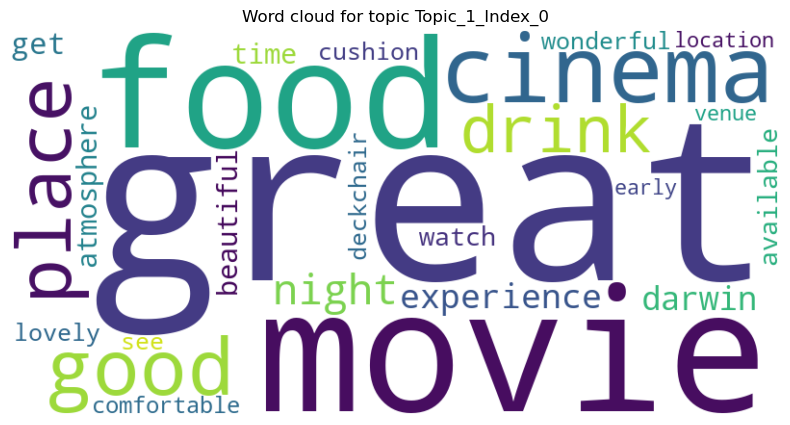

In [73]:
#movie theatre
topic_modelling(dff.loc[dff["categoryName"]=='Movie theater'],1)

In [74]:
for n,i in dff.loc[dff["categoryName"]=='Movie theater'].iterrows():
    if "comfortable" in i["text"].split(" "):
        print(i["text"])
        print(i['year_published'])
        print("*******")
        print(i["title"])

What an experience, looking up into the sky. Great Movie 'Tina' playing. Met up with friends it was a special place. It could do with some more comfortable seating as friends' deckchairs broke halfway through the movie.
2025
*******
Deckchair Cinema
Fabulous spot with meals and drinks. The chairs are not overly comfortable but there are plenty of cushions. Very chilled vibe. It did get quite busy on a Thursday so always good to get there early and grab a meal. You can pick up a free book to take away if you’re after some holiday reading.
2025
*******
Deckchair Cinema
Had such a lovely evening here. Very reasonably priced drinks, and comfortable deck chairs to watch the film. Just wish I didn’t live on the other side of the world so I could come back more often!
2025
*******
Deckchair Cinema
Luxury at its best. Buy food, alcoholic drinks. Icecream. You are asked to bring your own plate and cutlery for the food. Very comfortable relaxed atmosphere. Byo cushion if you like but they have s

In [75]:
import numpy as np

## Lets analyze is LOcal guide ******************************

In [76]:
dff.groupby("isLocalGuide")["sentiment"].value_counts()

isLocalGuide  sentiment
False         Positive     110
              Neutral       17
              Negative       7
True          Positive     828
              Neutral       75
              Negative      37
Name: count, dtype: int64

We see a clear segregation between True or False in relation to sentiment counts, as there are high counts of each sentiment in records that have True

In [77]:
#which titles had local guides
dff.groupby("isLocalGuide")["title"].value_counts()

isLocalGuide  title                                           
False         Kakadu National Park                                 17
              Museum and Art Gallery of the Northern Territory     16
              RFDS Darwin Tourist Facility                         14
              Uluṟu-Kata Tjuṯa National Park                       14
              Pudakul Aboriginal Cultural Tours                    11
              Deckchair Cinema                                     10
              Darwin Military Museum                                9
              Litchfield National Park                              9
              Parap Village Markets                                 8
              Darwin Aviation Museum                                7
              Nightcliff Market                                     6
              Nitmiluk National Park                                6
              Charles Darwin National Park                          6
              Outstation Ga

In [78]:
#RETURNING TITLES THAT DON'T HAVE TOURIST GUIDES OVERAL
no_guide_list=[]
for n in dff.loc[dff["isLocalGuide"]==False]["title"].unique():
     if n not in dff.loc[dff["isLocalGuide"]==True]["title"].unique():
         no_guide_list.append(n)
         
print(no_guide_list)         

[]


In [79]:
#does review length average vary based on islocal true false
dff.groupby("isLocalGuide")["review_text_count"].describe()

,count,mean,std,min,25%,50%,75%,max
isLocalGuide,,,,,,,,
False,134.0,28.462687,28.537973,1.0,8.00,18.5,39.75,144.0
True,940.0,34.113830,41.429500,1.0,10.75,22.0,44.00,497.0


In [80]:
_,p_value=st.ttest_ind(a=dff.loc[dff["isLocalGuide"]==True]["review_text_count"],b=dff.loc[dff["isLocalGuide"]==False]["review_text_count"],equal_var=False)
if p_value >=0.05:
    print("Accept H0: There is no difference in review text count based on is local guide")
else:
    print("Accept H1: There is a difference in review text count based on is local guide")

Accept H1: There is a difference in review text count based on is local guide


We see that there is a difference in review text length based on there being a local guide or not, with instance of True, having longer reviews compared to those of False.

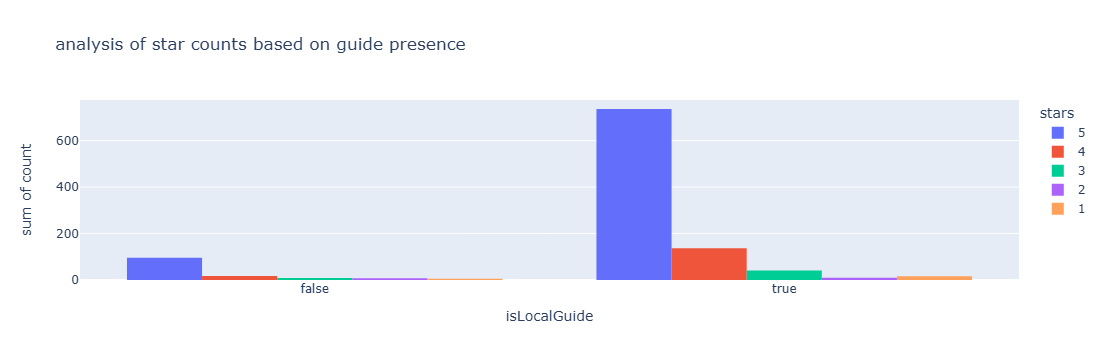

In [81]:
#compare sentiment counts based on is local guide
guide_to_stars=dff.groupby("isLocalGuide")["stars"].value_counts().to_frame().reset_index()
fig_z=px.histogram(guide_to_stars,x="isLocalGuide",y="count",color="stars",title="analysis of star counts based on guide presence",barmode="group")
fig_z.show()

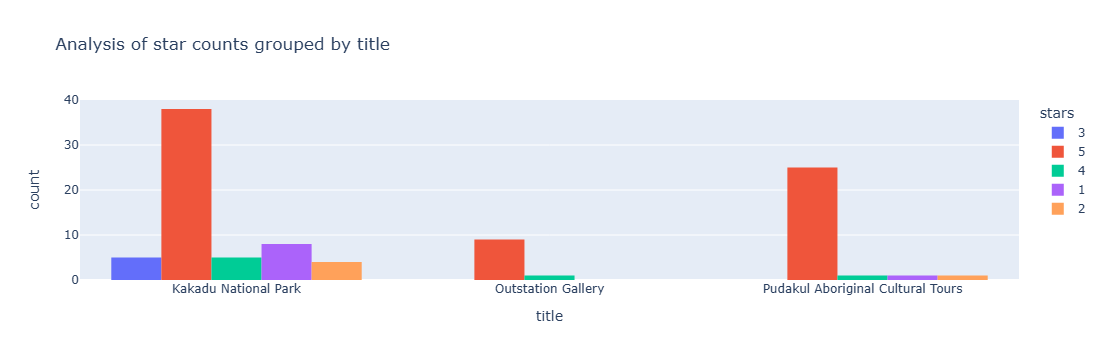

In [82]:
low_guide_titles=dff.loc[(dff["title"]=="Outstation Gallery") | (dff["title"]=="Pudakul Aboriginal Cultural Tours") |  (dff["title"]=="Kakadu National Park")]
fig_t=px.histogram(low_guide_titles,x="title",color="stars",title="Analysis of star counts grouped by title",barmode="group")
fig_t.show()

## Conclusion **********
The presence of a local guide influence the length of the overal review text, with the average review text tourist attractions with guides being 34 and those without being 28. This is also backed by a two sample t test and by the distribution of stars based on local guide presence. 88% of the 5 star reviews went to attractions with guides. 
Even though there aren't any museums or national parks that don't provide local guides in general, some tourist attractions like Outstation Gallery, Pudakul Aboriginal Cultural Tours and Kakadu National Park would see increased positive 5 stars counts and 3,4 stars as well.

In [83]:
#which category has the highest positive sentiment
dff.groupby("categoryName")["sentiment"].value_counts()

categoryName        sentiment
Art gallery         Positive       9
                    Negative       1
Corporate office    Positive      27
                    Negative       1
Farmers' market     Positive      49
                    Neutral        7
                    Negative       1
Market              Positive      50
                    Neutral        6
                    Negative       5
Movie theater       Positive      61
                    Negative       2
                    Neutral        2
Museum              Positive     276
                    Negative      10
                    Neutral       10
National park       Positive     243
                    Neutral       60
                    Negative      16
Tourist attraction  Positive      93
                    Neutral        1
                    Negative       1
War museum          Positive     130
                    Negative       7
                    Neutral        6
Name: count, dtype: int64

## Museums had the largest positive sentiments and national parks had the largest amount of negative reviews(16).

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1)]
In stage 0: transferred 0 clusters with 1 clusters populated
In stage 1: transferred 0 clusters with 1 clusters populated
In stage 2: transferred 0 clusters with 1 clusters populated
In stage 3: transferred 0 clusters with 1 clusters populated
In stage 4: transferred 0 clusters with 1 clusters populated
In stage 5: transferred 0 clusters with 1 clusters populated
In stage 6: transferred 0 clusters with 1 clusters populated
In stage 7: transferred 0 clusters with 1 clusters populated
In stage 8: transferred 0 clusters with 1 clusters populated
In stage 9: transferred 0 clusters with 1 clusters populated
In stage 10: transferred 0 clusters with 1 clusters populated
In stage 11: transferred 0 clusters with 1 clusters populated
In stage 12: transferred 0 clusters with 1 clusters populated
In stage 13: transferred 0 clusters with 1 clusters populate

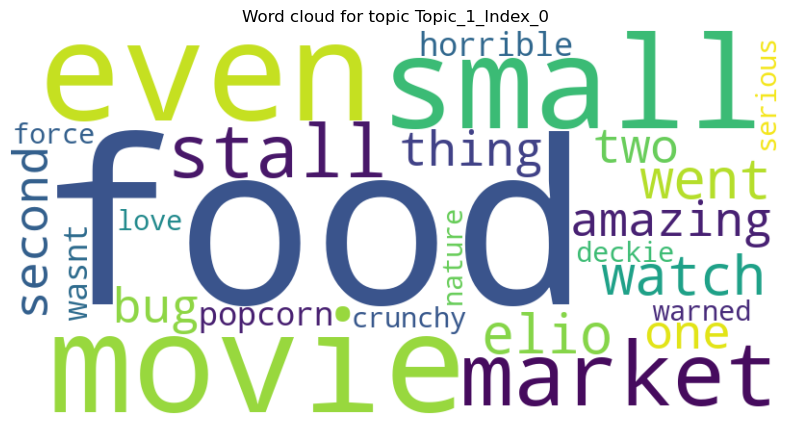

In [90]:
#investigating the negative reviews under title National Park
movie=dff.loc[(dff["categoryName"]=="Movie theater") | (dff["categoryName"]=="Market") | (dff["categoryName"]=="Farmers' market")]
topic_modelling(movie.loc[movie["sentiment"]=="Negative"],1)

In [96]:
for n,i in movie.loc[movie["sentiment"]=="Negative"].iterrows():
    if "warned" in i["cleaned_text"].split(" "):
        print(i["text"])
        print(i['year_published'])
        print("*******")
        print(i["title"])

I went there watch elio and it was amazing but two things one it had some bugs in the movie second the popcorn was horrible it wasn’t even crunchy you have been warned I am serious
2025
*******
Deckchair Cinema


In [86]:
len(dff.loc[dff["year_published"]=="2025"])

564

In [87]:
dff.groupby("year_published")["stars"].value_counts()

year_published  stars
2016            5          3
2017            4          3
                5          1
2018            5          8
                4          2
2019            5         14
                4          3
2020            5         10
                4          1
2021            5         37
                4          6
                3          3
                2          1
2022            5         82
                4         19
                3          2
                2          1
2023            5         88
                4         27
                3          7
                1          4
                2          2
2024            5        151
                4         14
                3         11
                1          6
                2          4
2025            5        438
                4         79
                3         27
                1         11
                2          9
Name: count, dtype: int64

In [88]:
dff.loc[dff["num_reviews_class"]=="Low"]['sentiment'].value_counts()

KeyError: 'num_reviews_class'

In [ ]:
dff.loc[dff["sentiment"]=="Positive"]['title'].value_counts()

In [ ]:
dff.sentiment.value_counts()

We see that reviews that are under Medium to High in the num_review_class, are all positive sentiments, and under Low, the sentiment classes vary.

The RFDS, Art and Galler; and Military museum are the museums with reviews under the High class. We also see that Museum and Art Gallery of the Northern Territory has the highest number of positive sentiments, followed by thr Aviation and Military museums with just a unit of 10 difference.


## Bivariate analysis

Categorical to categorical

1. Could those that didn't have guides have received negative reviews?
2. Review context reservation recommended: This describes the review based on the tourist being required to reserve the trip or not. 85 percent of the reviews didn't need to reserve, and 8 percent were unsure, leaving only 6 percent who needed to reserve. Do the sentiments and text cloud words differ based on this?
3. Review context viewed on: This specifies the days the tourist visited the museum, 78 percent visited on the weekdays, 24 on the weekend and the rest on public holidays. Analyze this to sentiment classes?
4. Review context wait time: This specifies the review based on how long the tourist had to wait to begin the tour. 357 records didn't need to wait. Is this column related to reservation recommended column? Also did those who waited leave negative reviews?
5. Analyze the texts to identify if the tourist was alone or with others and compare with these columns in relation to the sentiment.

Numeric to numeric

1. We can create a column called reviewers_review_number_class and create groups, then identify what makesup these different variations and how they relate to the sentiment?
2. Does review number of reviews correlate to stars and reviews count?
3. Does stars correlate to review counts?


In [89]:
dff.categoryName.unique()

array(['War museum', 'Museum', 'Tourist attraction', 'National park',
       'Movie theater', 'Market', 'Art gallery', "Farmers' market",
       'Corporate office'], dtype=object)

In [91]:
len(movie.loc[movie["sentiment"]=="Negative"])

8